# 01. Regressão Linear — Parte 1
## Beta CAPM: se o mercado cair 10%, quanto cai ITUB3?

---

Este notebook aplica o **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — o framework de referência para projetos de ciência de dados — ao problema de estimação do Beta CAPM de ITUB3 via regressão linear simples.

```
┌─────────────────────────────────────────────────────────────────┐
│                          CRISP-DM                               │
│                                                                 │
│  1. Business        2. Data          3. Data                    │
│  Understanding  →   Understanding →  Preparation                │
│       ↑                                          ↓              │
│  6. Deployment  ←   5. Evaluation  ← 4. Modeling               │
└─────────────────────────────────────────────────────────────────┘
```

| Fase | Nome | O que fazemos aqui |
|---|---|---|
| **1** | Business Understanding | Cenário de risco, teoria CAPM, hipótese β > 1 |
| **2** | Data Understanding | Coleta de dados de mercado + qualidade |
| **3** | Data Preparation | Reamostragem mensal, retornos logarítmicos, EDA |
| **4** | Modeling | Regressão OLS — estimação de α, β, R² |
| **5** | Evaluation | Diagnóstico de resíduos — o modelo é confiável? |
| **6** | Deployment | Sumário executivo para o comitê de alocação |

<a id="sec-bu"></a>

---

## Fase 1 — Business Understanding (Entendimento do Negócio)

> *No CRISP-DM, nenhuma linha de código é escrita antes de responder: qual é o problema de negócio, o que constitui uma boa resposta e qual modelo vai produzi-la.*

### 1.1 Pergunta de negócio

Você é analista de risco de mercado. O gestor sênior te chama antes do comitê de alocação:

> *"O fundo tem uma posição relevante em ITUB3. Se o mercado cair 10% amanhã, quanto essa ação deve cair? Ela amplifica o mercado ou atenua?"*

Essa pergunta tem uma resposta quantitativa. O **Beta do CAPM**, estimado por regressão linear simples, é a ferramenta para encontrá-la.

---

### 1.2 Justificativa teórica

Em um mercado financeiro, nenhum ativo se move de forma completamente isolada. Há um fator comum que afeta todos ao mesmo tempo — crises, expansões, choques de política monetária. Esse é o **risco sistemático**: o risco que a diversificação não consegue eliminar.

O **CAPM** (Capital Asset Pricing Model, Sharpe 1964) formaliza essa ideia: o retorno de qualquer ativo se decompõe em dois componentes:

$$\underbrace{\beta \cdot r_{\text{mercado}}}_{\text{sistemático — explicado pelo mercado}} \;+\; \underbrace{\varepsilon}_{\text{idiossincrático — específico do ativo}}$$

O Ibovespa é o proxy natural para o "mercado" no Brasil — composto pelas ações mais líquidas da B3, captura o comportamento médio do mercado doméstico. Para bancos, a ligação é especialmente forte. O canal de transmissão é direto:

```
Ibovespa cai → apetite por risco ↓ → venda de ativos de risco (bancos incluídos)
             → expectativa de recessão ↑ → inadimplência esperada ↑
               → valuation do banco ↓ (provisão maior, margem financeira menor)
```

Bancos são **pró-cíclicos por natureza**: seus lucros crescem na expansão (crédito aquecido, spreads maiores) e contraem na recessão (inadimplência, queda de volume). A forte correlação esperada entre ITUB3 e o Ibovespa não é coincidência — é estrutural.

> **Referência:** Banco Central do Brasil. *Relatório de Estabilidade Financeira*, edições 2015–2024. Disponível em: [https://www.bcb.gov.br/publicacoes/ref](https://www.bcb.gov.br/publicacoes/ref). Cada edição inclui análise da pró-ciclicidade do crédito bancário e da exposição sistêmica dos bancos ao ciclo econômico — ver seção "Risco de Crédito" de cada edição.

---

### 1.3 Formalização: a Linha de Mercado do Título (SML)

**Por que a SML?** O CAPM prediz uma relação linear entre o retorno esperado de qualquer ativo e sua exposição ao risco sistemático (β). A **SML** (*Security Market Line*) é a representação geométrica dessa previsão: uma reta no espaço (β, E[r]) com inclinação igual ao prêmio de risco de mercado. Usamos a SML porque ela conecta diretamente nossa pergunta — "quanto β vale para ITUB3?" — à teoria que justifica estimar β por regressão linear.

**A forma teórica real (CAPM completo):**

$$E[r_i] = r_f + \beta_i \cdot \underbrace{(E[r_m] - r_f)}_{\text{prêmio de risco de mercado}}$$

onde $r_f$ é a taxa livre de risco (Selic, no Brasil) e $E[r_m] - r_f$ é o excesso de retorno que o mercado paga por unidade de risco sistemático.

**Por que usamos a versão empírica?** A SML teórica trabalha com *retornos esperados* — que nunca observamos. Para estimar β, substituímos retornos esperados por retornos realizados e adicionamos um termo de erro para capturar a aleatoriedade. Esse é o **Modelo de Mercado** (*Market Model*), estabelecido por Black, Jensen & Scholes (1972):

| Versão | Forma matemática | Quando usar |
|---|---|---|
| **Teórica (CAPM/SML)** | $E[r_i] = r_f + \beta_i(E[r_m]-r_f)$ | Fundamento teórico; não estimável diretamente |
| **Empírica completa** | $(r_{i,t}-r_{f,t}) = \alpha_i + \beta_i(r_{m,t}-r_{f,t}) + \varepsilon_t$ | Rigorosa; exige dados diários de Selic |
| **Simplificada (este notebook)** | $r_{i,t} = \alpha + \beta \cdot r_{m,t} + \varepsilon_t$ | Prática; β praticamente idêntico ao da completa |

**A simplificação é válida para estimar β?** Sim. A Selic mensal (≈ 0,5–1% a.m. no período) é subtraída de *ambos* os lados da versão completa. Quando ela é aproximadamente constante ao longo do tempo, o efeito sobre a *inclinação* β é mínimo. A diferença aparece no intercepto α — razão pela qual não fazemos inferência formal sobre α neste notebook.

| Parâmetro | Nome | O que mede |
|---|---|---|
| $\beta$ | Beta do CAPM | Quanto r_ITUB3 se move para cada 1% do Ibovespa |
| $\alpha$ | Alfa (versão aproximada de Jensen) | Excesso de retorno médio além do explicado pelo mercado |
| $\varepsilon_t$ | Retorno anormal | O que o modelo não consegue explicar |

---

### 1.4 Hipótese e critério de sucesso

Se bancos são pró-cíclicos, o Beta de ITUB3 deve ser **maior que 1** — a ação amplifica os movimentos do mercado.

| β | Comportamento esperado |
|---|---|
| β > 1 | Ibovespa cai 10% → ITUB3 cai *mais* que 10% |
| β = 1 | Ibovespa cai 10% → ITUB3 cai exatamente 10% |
| β < 1 | Ibovespa cai 10% → ITUB3 cai *menos* que 10% |

A evidência histórica apoia β > 1: no crash COVID (mar/2020) o Ibovespa caiu −29% e ITUB3 caiu além disso; na recuperação seguinte, ITUB3 subiu acima do índice.

**Critério de sucesso — R² > 0,50:** o Beta só é uma resposta confiável quando o risco sistemático domina o risco específico. Um R² < 0,50 significaria que mais da metade da variância de ITUB3 é idiossincrática — eventos específicos do banco (resultado trimestral, mudança de CEO, investigação regulatória) — não movimentos do mercado. Nesse caso, a previsão "Ibovespa −10% → ITUB3 −X%" perderia poder preditivo relevante.

O limite de 0,50 é uma convenção consolidada em análise de risco de mercado. Fama & French (1993) documentam que grandes empresas de setores cíclicos integrados ao mercado exibem R² de 0,50 a 0,80 contra um índice de mercado. Para ITUB3 — uma das maiores ações do Ibovespa por peso e liquidez — R² abaixo de 0,50 seria uma anomalia que exigiria investigação do framework, não do modelo.

> **Conclusão da Fase 1:** problema definido, modelo escolhido, hipótese formulada. A Fase 2 verifica se os dados disponíveis são suficientes para respondê-la.

In [14]:
# ── Manipulação de dados ──────────────────────────────────────────────────────
import warnings
import numpy as np          # álgebra vetorial: cálculos numéricos sobre arrays
import pandas as pd         # DataFrames: estrutura principal para séries temporais

# ── Coleta de dados de mercado ────────────────────────────────────────────────
import yfinance as yf       # acessa a API pública do Yahoo Finance sem autenticação

# ── Visualização ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt  # engine de gráficos
import seaborn as sns            # camada de alto nível sobre matplotlib

# ── Estatística ───────────────────────────────────────────────────────────────
from scipy import stats          # correlação de Pearson e testes estatísticos

# ── Modelo de regressão ───────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression  # OLS: minimiza soma dos quadrados dos resíduos
from sklearn.metrics import r2_score               # R²: proporção da variância explicada pelo modelo

# ── Diagnóstico de resíduos ───────────────────────────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess  # curva suave local para detectar padrões

warnings.filterwarnings('ignore')
np.random.seed(42)  # garante reprodutibilidade em qualquer operação com aleatoriedade

# Estilo visual padrão para todos os gráficos do notebook
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

<a id="sec-du"></a>

---

## Fase 2 — Data Understanding (Entendimento dos Dados)

> *O objetivo é responder: os dados que temos são suficientes para o modelo? Qual é sua qualidade e cobertura temporal?*

### Coleta e qualidade dos dados

In [15]:
# 10 anos cobrem múltiplos ciclos — bull market (2016–2019), crash COVID (2020) e ciclo de alta de juros (2021–2023)
# Um Beta estimado em apenas um regime seria pouco confiável
START, END = '2015-01-01', '2024-12-31'

# auto_adjust=True: preços ajustados por dividendos e desdobramentos
# Sem esse ajuste, splits de ações criam quedas artificiais que distorceriam o Beta
raw_itub = yf.download('ITUB3.SA', start=START, end=END, auto_adjust=True, progress=False)
raw_ibov = yf.download('^BVSP',    start=START, end=END, auto_adjust=True, progress=False)

# .squeeze() converte DataFrame de uma coluna em Series simples
preco_itub = raw_itub['Close'].squeeze().rename('ITUB3')
preco_ibov = raw_ibov['Close'].squeeze().rename('IBOV')

# Verificação de qualidade: cobertura temporal e integridade
print(f'ITUB3: {len(preco_itub)} pregões | {preco_itub.index.min().date()} a {preco_itub.index.max().date()}')
print(f'IBOV:  {len(preco_ibov)} pregões | {preco_ibov.index.min().date()} a {preco_ibov.index.max().date()}')
print(f'\nValores ausentes — ITUB3: {preco_itub.isna().sum()} | IBOV: {preco_ibov.isna().sum()}')
print()
pd.DataFrame({'ITUB3': preco_itub, 'IBOV': preco_ibov}).describe().round(2)

ITUB3: 2487 pregões | 2015-01-02 a 2024-12-30
IBOV:  2479 pregões | 2015-01-02 a 2024-12-30

Valores ausentes — ITUB3: 0 | IBOV: 0



,ITUB3,IBOV
count,2487.00,2479.00
mean,14.01,92190.99
std,4.21,27064.07
min,5.78,37497.00
25%,11.18,66309.50
50%,14.40,99404.00
75%,16.76,114913.00
max,24.24,137344.00


**Qualidade e relevância dos dados:**

- **Integridade:** sem valores ausentes — as séries estão completas para o período.
- **Diferença de pregões:** ITUB3 tipicamente registra mais linhas do que o índice `^BVSP` no Yahoo Finance. Isso ocorre porque o Ibovespa é um índice calculado pelo provedor — e em algumas datas históricas o dado de fechamento do índice não está disponível no Yahoo Finance, mesmo que o mercado tenha funcionado normalmente naquele dia. Não se trata de ausência de negociação, mas de lacuna na base de dados do índice. Como `dropna()` é aplicado na Fase 3 sobre os retornos, datas discordantes são eliminadas automaticamente — sem perda de informação relevante.
- **Cobertura:** 10 anos abrangem múltiplos regimes — bull market (2016–2019), crash COVID (2020) e ciclo de alta de juros (2021–2023). Um Beta estimado em apenas um regime seria pouco confiável.
- **Frequência diária:** ~2.500 pregões por ativo. A Fase 3 reamostrar para frequência mensal — o Beta mensal reduz ruído de curtíssimo prazo e é a convenção dominante em análise de risco de mercado.

> **Próximo passo:** a Fase 3 transforma esses dados brutos em retornos logarítmicos mensais — o formato que o modelo OLS precisa.

<a id="sec-dp"></a>

---

## Fase 3 — Data Preparation (Preparação dos Dados)

> *Transformamos os dados brutos no formato exato que o algoritmo da Fase 4 precisa: retornos logarítmicos mensais, sem valores ausentes. Em seguida, exploramos visualmente os dados preparados para confirmar a premissa de linearidade.*

### 3.1 Transformações

Duas transformações são necessárias:

1. **Reamostragem mensal** (`resample('ME').last()`): pega o preço do último pregão de cada mês, reduzindo ~2.500 observações diárias para ~120 mensais e eliminando ruído de curtíssimo prazo.

2. **Retorno logarítmico** ($r_t = \ln(P_t / P_{t-1})$): preferido em finanças porque é aditivo no tempo, mais simétrico e aproxima o retorno aritmético para variações pequenas. É a unidade de análise do Beta CAPM.

In [16]:
# resample('ME').last(): último pregão de cada mês — reduz ~2.500 observações diárias para ~120 mensais
# np.log(P_t / P_{t-1}): retorno logarítmico — aditivo no tempo, preferido em finanças
df = pd.DataFrame({
    'r_itub': np.log(preco_itub.resample('ME').last() / preco_itub.resample('ME').last().shift(1)),
    'r_ibov': np.log(preco_ibov.resample('ME').last() / preco_ibov.resample('ME').last().shift(1)),
}).dropna()  # dropna() remove o primeiro mês (NaN: não há mês anterior para calcular retorno)

print(f'Período: {df.index.min().strftime("%b/%Y")} a {df.index.max().strftime("%b/%Y")} | {len(df)} observações mensais')
print()
(df * 100).describe().round(2)

Período: Feb/2015 a Dec/2024 | 119 observações mensais



,r_itub,r_ibov
count,119.00,119.00
mean,0.90,0.79
std,7.82,6.61
min,-25.86,-35.53
25%,-3.74,-3.10
50%,0.87,0.70
75%,6.82,5.53
max,16.44,15.67


**Verificação dos dados preparados:**

- **Volatilidade:** o desvio padrão de ITUB3 (7,82 p.p.) é maior que o do Ibovespa (6,61 p.p.) — primeiro indício quantitativo de que a ação amplifica movimentos do mercado.
- **Extremos:** o pior mês de ambas as séries coincide com março/2020 (crash COVID). Quando o mercado inteiro cai junto, não há diversificação possível — isso é **risco sistemático** em ação.
- **Suficiência:** 119 observações mensais são adequadas para OLS, mas o Beta médio de 10 anos pode mascarar instabilidades por regime — motivação para o Beta Rolling na Parte 2.

A exploração visual a seguir confirma se a estrutura linear que o OLS vai assumir está presente nos dados preparados.

### 3.2 Exploração Visual

Com os retornos calculados, verificamos visualmente a relação que o modelo vai formalizar. A pergunta central: os retornos mensais de ITUB3 e Ibovespa exibem uma relação linear — premissa do OLS — e quão forte é essa associação?

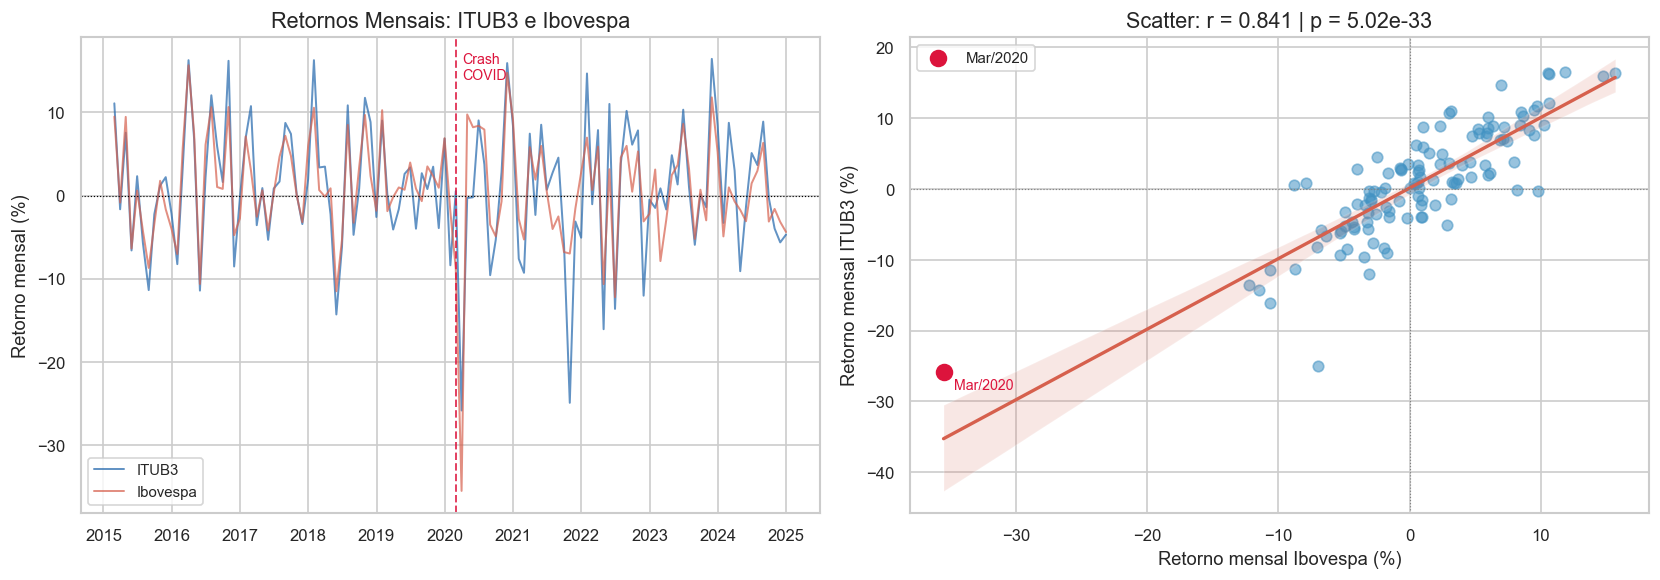

Correlação de Pearson: r = 0.8412 | p-valor = 5.0164e-33


In [17]:
# Correlação de Pearson: mede força e direção da relação linear entre −1 e +1
# p-valor testa H0: "a correlação é zero" — se p < 0.05, rejeitamos e concluímos que há relação
r_pearson, p_valor = stats.pearsonr(df['r_ibov'], df['r_itub'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Painel esquerdo: séries temporais sobrepostas ─────────────────────────────
# Objetivo: ver visualmente se as séries se movem juntas (co-movimento)
ax = axes[0]
ax.plot(df.index, df['r_itub'] * 100, alpha=0.7, linewidth=1.2, label='ITUB3', color='#2166ac')
ax.plot(df.index, df['r_ibov'] * 100, alpha=0.7, linewidth=1.2, label='Ibovespa', color='#d6604d')
ax.axhline(0, color='black', linewidth=0.7, linestyle=':')
# Marca o crash COVID: o pior mês simultâneo de ambas as séries
ax.axvline(pd.Timestamp('2020-03-01'), color='crimson', linestyle='--', linewidth=1.2, alpha=0.8)
ax.text(pd.Timestamp('2020-04-01'), 14, 'Crash\nCOVID', fontsize=8.5, color='crimson')
ax.set_ylabel('Retorno mensal (%)')
ax.set_title('Retornos Mensais: ITUB3 e Ibovespa')
ax.legend(fontsize=9)

# ── Painel direito: scatter com reta ajustada e IC 95% ───────────────────────
# Objetivo: verificar se a relação parece linear (premissa da regressão)
# ci=95: banda de confiança de 95% ao redor da reta — quanto mais estreita, mais precisa a estimativa
ax = axes[1]
sns.regplot(
    data=df * 100, x='r_ibov', y='r_itub',
    scatter_kws={'alpha': 0.55, 's': 40, 'color': '#4393c3'},
    line_kws={'color': '#d6604d', 'linewidth': 2},
    ci=95, ax=ax
)

# Destaca o crash de mar/2020: ponto mais extremo e de maior influência sobre o Beta
crash = df.loc['2020-03']
ax.scatter(crash['r_ibov'] * 100, crash['r_itub'] * 100,
           color='crimson', s=90, zorder=5, label='Mar/2020')
ax.annotate('Mar/2020', (crash['r_ibov'] * 100, crash['r_itub'] * 100),
            xytext=(6, -10), textcoords='offset points', fontsize=8.5, color='crimson')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.set_xlabel('Retorno mensal Ibovespa (%)')
ax.set_ylabel('Retorno mensal ITUB3 (%)')
ax.set_title(f'Scatter: r = {r_pearson:.3f} | p = {p_valor:.2e}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'Correlação de Pearson: r = {r_pearson:.4f} | p-valor = {p_valor:.4e}')

**O que a exploração revela:**

1. **Correlação forte e significante** — o p-valor indica que a probabilidade de observar r ≈ 0,84 por acaso é essencialmente zero. Há um fator comum movendo os dois ativos.

2. **Relação visualmente linear** — a nuvem de pontos se organiza em torno de uma reta sem curvatura evidente. Isso valida a premissa de linearidade do OLS para este par.

3. **Mar/2020 (crash COVID)** — ponto extremo, distante da nuvem central. Observações muito afastadas da maioria podem exercer influência desproporcional sobre qualquer reta ajustada — isso será auditado na Fase 5.

> **Conclusão da Fase 3:** dados preparados e explorados. 119 observações mensais, sem ausentes. A linearidade visual confirma a premissa central do modelo. A Fase 4 ajusta o OLS.

<a id="sec-modeling"></a>

---

## Fase 4 — Modeling (Modelagem)

> *Com os dados preparados e a hipótese formulada na Fase 1, ajustamos o modelo OLS para estimar α e β.*

### 4.1 Por que regressão linear simples é a escolha certa aqui

Quatro condições justificam a escolha:

1. **Linearidade teórica:** o CAPM *prediz* que a relação entre r_ITUB3 e r_IBOV é linear — é o que a teoria diz que deve ser. A SML é uma reta por construção. A regressão linear não é uma aproximação funcional escolhida por conveniência: é a forma funcional que a teoria especifica.

2. **Confirmação empírica:** a exploração visual da Fase 3 mostrou nuvem de pontos organizada em torno de uma reta sem curvatura relevante. Teoria e dados concordam.

3. **Canônico na literatura:** o Modelo de Mercado estimado por OLS é o método padrão para Beta desde Black, Jensen & Scholes (1972). Modelos mais complexos (Fama-French, GARCH-β) *partem* do OLS e adicionam componentes específicos — não o substituem como ponto de partida.

4. **Estacionariedade:** retornos mensais oscilam em torno de uma média relativamente estável, sem tendência de longo prazo. Séries de preços, em contraste, têm tendência de alta e violariam as premissas do OLS.

### 4.2 Parâmetros e hiperparâmetros

| Tipo | Nome | Valor | Como é determinado |
|---|---|---|---|
| **Parâmetro** | β (Beta CAPM) | estimado dos dados | OLS minimiza a SSR |
| **Parâmetro** | α (intercepto) | estimado dos dados | OLS minimiza a SSR |
| **Hiperparâmetro** | `fit_intercept` | `True` (sklearn padrão) | decisão de modelagem: incluímos α |
| **Hiperparâmetro** | Frequência dos retornos | mensal | decisão de design — Fase 3 |
| **Hiperparâmetro** | Janela temporal | 2015–2024 (10 anos) | decisão de design — Fase 2 |
| **Hiperparâmetro** | Transformação | log-retorno | decisão de design — Fase 3 |

> Diferença central: **parâmetros** são aprendidos dos dados (o OLS os calcula). **Hiperparâmetros** são escolhas de design que precedem o ajuste — mudar um hiperparâmetro pode mudar β de forma significativa (um Beta de janela 5 anos difere do de 10 anos; um Beta diário difere do mensal).

### 4.3 Critério de ajuste e o que interpretar

O OLS escolhe α e β que minimizam a soma dos quadrados dos resíduos:

$$\min_{\alpha,\,\beta} \sum_{t=1}^{n} \left(r_{\text{ITUB3},t} - \alpha - \beta \cdot r_{\text{IBOV},t}\right)^2$$

**O que interpretar nos resultados:**

| Saída | O que mede | O que observar |
|---|---|---|
| **β** | Sensibilidade ao mercado | > 1: amplifica / ≈ 1: replica / < 1: atenua |
| **α** | Retorno médio não explicado pelo mercado | Comparar com zero — teste formal na Parte 2 |
| **R²** | Fração da variância de ITUB3 explicada pelo Ibovespa | Referência: > 0,50 confirma dominância do risco sistemático |
| **RMSE** | Erro médio mensal do modelo | Incerteza ao redor de cada previsão pontual |

**Uma nota sobre α e a Hipótese de Eficiência de Mercado (HEM):** a tabela acima diz "comparar com zero" para α — e esse zero vem de uma previsão teórica. Em mercados eficientes, retornos anormais persistentes são arbitrados e eliminados. O CAPM sob HEM prediz $\alpha = 0$: não existe retorno "grátis" acima do que o Beta justifica. Portanto, zero é o *baseline de comparação* para α — não um valor imposto. Um α diferente de zero estimado pelo OLS pode ser ruído amostral; para concluir que α ≠ 0 seria necessário um t-test formal. O sklearn não fornece t-estatísticas para coeficientes — lacuna preenchida pelo `statsmodels` na Parte 2.

> **Nota técnica:** `sklearn.LinearRegression` executa OLS puro e retorna coeficientes estimados. Não fornece t-estatísticas, p-valores ou intervalos de confiança. Isso é suficiente para estimação pontual de β, mas insuficiente para inferência formal.

In [18]:
# sklearn exige que X seja uma matriz 2D (linhas = observações, colunas = features)
# reshape(-1, 1): converte o array 1D [n] para matriz [n, 1] — 119 meses, 1 variável
X = df['r_ibov'].values.reshape(-1, 1)  # variável explicativa: retorno do Ibovespa
y = df['r_itub'].values                 # variável dependente: retorno de ITUB3

# LinearRegression() usa OLS internamente:
# encontra α e β que minimizam Σ(y_i - α - β·x_i)² — a soma dos quadrados dos erros
modelo = LinearRegression()
modelo.fit(X, y)              # ajusta o modelo aos dados históricos
y_pred = modelo.predict(X)   # y_pred[i] = α + β × r_ibov[i]  para cada mês i
residuos = y - y_pred         # resíduo = o que o modelo não conseguiu explicar

# Extrai os parâmetros estimados pelo OLS
alfa = modelo.intercept_  # Alfa de Jensen: retorno médio não explicado pelo mercado
beta = modelo.coef_[0]    # coef_ é sempre um array mesmo com 1 feature — [0] extrai o escalar Beta

# Métricas de qualidade do ajuste
r2   = r2_score(y, y_pred)              # R² = SSR/SST: proporção da variância explicada
rmse = np.sqrt(np.mean(residuos ** 2))  # raiz do erro quadrático médio — na unidade original (decimal)

print('=== Modelo estimado ===')
print(f'  r_ITUB3 = {alfa*100:.4f}% + {beta:.4f} × r_IBOV')
print()
print(f'  Alfa de Jensen  α = {alfa*100:.4f}% ao mês  ({((1+alfa)**12-1)*100:+.2f}% a.a.)')
print(f'  Beta CAPM       β = {beta:.4f}')
print()
print(f'  R²   = {r2:.4f}  ({r2*100:.1f}% da volatilidade de ITUB3 é sistemática)')
print(f'  RMSE = {rmse*100:.2f} p.p.  (erro médio mensal do modelo)')

=== Modelo estimado ===
  r_ITUB3 = 0.1157% + 0.9956 × r_IBOV

  Alfa de Jensen  α = 0.1157% ao mês  (+1.40% a.a.)
  Beta CAPM       β = 0.9956

  R²   = 0.7076  (70.8% da volatilidade de ITUB3 é sistemática)
  RMSE = 4.21 p.p.  (erro médio mensal do modelo)


**O Ibovespa explica ITUB3?** Sim — e há evidência convergente em três camadas:

| Evidência | Valor | Interpretação |
|---|---|---|
| Correlação de Pearson r | ≈ 0,84 | Relação linear forte — calculada na Fase 3 |
| p-valor da correlação | ≈ 0 | Probabilidade de r = 0,84 por acaso é essencialmente zero |
| R² = 0,71 | 70,8% | 71% da variância mensal de ITUB3 é explicada pelo Ibovespa |

Vale notar: a correlação de Pearson com p-valor ≈ 0 é matematicamente equivalente ao t-test da hipótese H0: β = 0 na regressão simples. Isso significa que, mesmo sem o sklearn fornecer t-estatísticas para β diretamente, a evidência do teste de correlação já implica que β é estatisticamente significante.

**Resultado vs. hipótese:** β = 0,9956 — praticamente igual a 1. Para fins práticos, ITUB3 *replicou* o mercado ao longo do período, não amplificou. A hipótese de β > 1 não se confirmou.

Isso não invalida o raciocínio teórico. O período 2015–2024 mistura regimes muito distintos — bull market, COVID, ciclo de alta de juros — e um Beta *médio* de 10 anos pode mascarar períodos em que ITUB3 claramente amplificou e outros em que atenuou. O Beta Rolling (Parte 2) vai revelar essa instabilidade.

**R² = 0,71** é elevado para uma ação individual — a maioria das ações brasileiras fica entre 0,30 e 0,60 contra o Ibovespa. Confirma que o risco de ITUB3 é predominantemente sistemático, consistente com a tese de pró-ciclicidade. O que sobra (29%) é risco específico do Itaú: gestão, inadimplência da carteira, regulação.

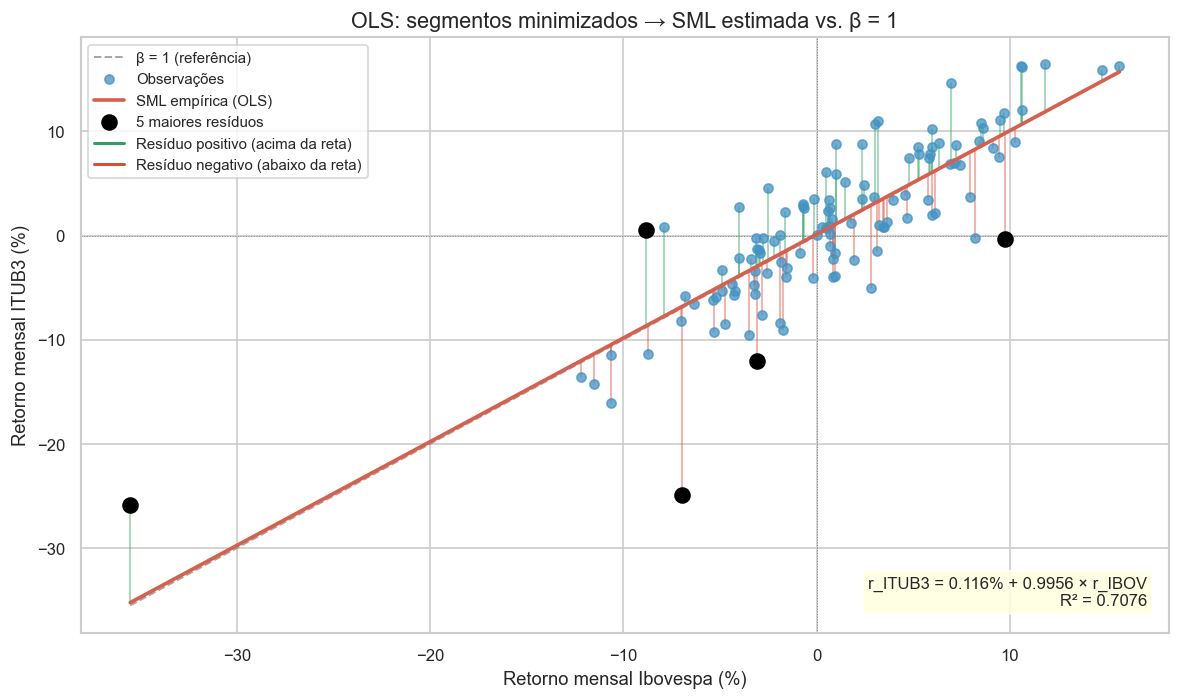

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

x_linha = np.linspace(X.min(), X.max(), 200)

# Diagonal de 45°: representa β = 1 — ITUB3 replicando o mercado perfeitamente
# A posição da reta OLS em relação a esta diagonal revela se β > 1 ou β < 1
ax.plot(x_linha * 100, x_linha * 100,
        color='gray', linewidth=1.2, linestyle='--', alpha=0.7, label='β = 1 (referência)', zorder=1)

# Segmentos verticais: cada linha conecta o ponto observado ao seu valor predito na reta
# É exatamente isso que o OLS minimiza — a soma dos quadrados dessas distâncias
# X.flatten(): X foi reshape para 2D ([n,1]) para o sklearn; flatten() volta para 1D ([n]) para iterar
for xi, yi, ypi, ei in zip(X.flatten(), y, y_pred, residuos):
    cor = '#2ca25f' if ei >= 0 else '#e34a33'  # verde = acima da reta, vermelho = abaixo
    ax.plot([xi * 100, xi * 100], [ypi * 100, yi * 100],
            color=cor, linewidth=0.9, alpha=0.55, zorder=2)

# Pontos observados
ax.scatter(X * 100, y * 100, s=30, color='#4393c3', alpha=0.75, zorder=3, label='Observações')

# Reta OLS ajustada: SML empírica — resultado final da minimização
ax.plot(x_linha * 100, (alfa + beta * x_linha) * 100,
        color='#d6604d', linewidth=2.2, zorder=4, label='SML empírica (OLS)')

# Destaca os 5 maiores resíduos — os pontos que mais "puxam" a reta
# argsort ordena os índices em ordem crescente de |resíduo|; [-5:] pega os 5 últimos (maiores)
idx_top = np.argsort(np.abs(residuos))[-5:]
ax.scatter(X.flatten()[idx_top] * 100, y[idx_top] * 100,
           s=80, color='black', zorder=5, label='5 maiores resíduos')

# ax.plot([], []) cria uma entrada de legenda sem desenhar nada no gráfico (proxy legend)
# Necessário porque os segmentos foram adicionados via loop e não têm label individual
ax.plot([], [], color='#2ca25f', linewidth=1.8, label='Resíduo positivo (acima da reta)')
ax.plot([], [], color='#e34a33', linewidth=1.8, label='Resíduo negativo (abaixo da reta)')

ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.6, linestyle=':')
ax.set_xlabel('Retorno mensal Ibovespa (%)')
ax.set_ylabel('Retorno mensal ITUB3 (%)')
ax.set_title('OLS: segmentos minimizados → SML estimada vs. β = 1')
ax.legend(fontsize=9, loc='upper left')

# Equação estimada e R² para referência rápida durante a apresentação
equacao = f'r_ITUB3 = {alfa*100:.3f}% + {beta:.4f} × r_IBOV\nR² = {r2:.4f}'
ax.text(0.98, 0.04, equacao, transform=ax.transAxes, fontsize=10,
        va='bottom', ha='right', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**

- **SML estimada (linha vermelha) quase coincide com a diagonal β = 1 (cinza)** — confirma visualmente β ≈ 1: na média do período, ITUB3 replicou o mercado em vez de amplificá-lo.
- **Segmentos maiores nos extremos** — os maiores erros concentram-se em meses de retornos intensos (alta ou baixa), não distribuídos uniformemente ao longo da reta. Esse padrão é heteroscedasticidade e será auditado na seção 5.
- **5 maiores resíduos (pontos pretos) não são aleatórios** — correspondem a eventos específicos (COVID, ciclo de juros) que moveram ITUB3 de forma descolada do Ibovespa. São exatamente os pontos que mais influenciam o β estimado.

In [20]:
# === Cenário: Ibovespa −10% ===
# Aplica o modelo estimado à pergunta que abriu o notebook

queda_ibov = -0.10  # queda hipotética de 10% no Ibovespa

# Previsão pontual do modelo: α + β × queda
retorno_previsto = alfa + beta * queda_ibov

# O RMSE mede o erro médio do modelo — uma diferença menor que o RMSE
# não é estatisticamente distinguível de β = 1 (o modelo não consegue separar os dois)
diferenca = abs(retorno_previsto) - abs(queda_ibov)  # positivo: amplifica; negativo: atenua
if abs(diferenca) < rmse:
    classificacao_str = (f'essencialmente igual ao mercado '
                         f'(diferença de {abs(diferenca)*100:.2f} p.p. < RMSE de {rmse*100:.2f} p.p.)')
elif diferenca > 0:
    classificacao_str = 'amplifica a queda do mercado'
else:
    classificacao_str = 'atenua a queda do mercado'

print('=== Cenário: Ibovespa −10% ===')
print()
print(f'  Previsão pontual : ITUB3 deve cair {abs(retorno_previsto)*100:.1f}%')
print(f'  Incerteza (RMSE) : ±{rmse*100:.1f} p.p.  →  intervalo [{(retorno_previsto - rmse)*100:.1f}%, {(retorno_previsto + rmse)*100:.1f}%]')
print()
print(f'  Classificação: ITUB3 {classificacao_str}')
print()
print(f'  Interpretação: β = {beta:.4f} ≈ 1; a diferença de {abs(diferenca)*100:.2f} p.p. entre')
print(f'  a queda prevista e os 10% exatos é menor que o erro médio do modelo ({rmse*100:.2f} p.p.).')
print(f'  Não há evidência suficiente para afirmar que ITUB3 amplifica ou atenua nesse cenário.')

=== Cenário: Ibovespa −10% ===

  Previsão pontual : ITUB3 deve cair 9.8%
  Incerteza (RMSE) : ±4.2 p.p.  →  intervalo [-14.1%, -5.6%]

  Classificação: ITUB3 essencialmente igual ao mercado (diferença de 0.16 p.p. < RMSE de 4.21 p.p.)

  Interpretação: β = 0.9956 ≈ 1; a diferença de 0.16 p.p. entre
  a queda prevista e os 10% exatos é menor que o erro médio do modelo (4.21 p.p.).
  Não há evidência suficiente para afirmar que ITUB3 amplifica ou atenua nesse cenário.


<a id="sec-eval"></a>

---

## Fase 5 — Evaluation (Avaliação)

> *No CRISP-DM, Evaluation responde: o modelo resolve o problema de negócio? Os resultados são confiáveis o suficiente para levar ao gestor?*

O modelo está estimado. Antes de levar os resultados ao comitê, a pergunta crítica: **as quatro premissas do Teorema de Gauss-Markov estão satisfeitas?**

A ferramenta de auditoria são os resíduos. Em finanças, esses erros têm nome: **retornos anormais** (*abnormal returns*). São os movimentos de ITUB3 que o Ibovespa não conseguiu explicar — eventos específicos do banco.

Em um modelo bem especificado, os resíduos são ruído puro: aleatórios, sem padrão, distribuídos em torno de zero. Qualquer estrutura encontrada é sinal de que o modelo deixou algo para trás.

| Premissa (Gauss-Markov) | Como verificamos | Ferramenta |
|---|---|---|
| **1. Linearidade** | LOWESS sem padrão + RESET não rejeita H0 | Gráfico + Teste RESET (Ramsey, 1969) |
| **2. Homocedasticidade** | Dispersão constante ao longo do eixo? | Gráfico de resíduos vs. preditos |
| **3. Independência** | Resíduos sem autocorrelação? | ⚠ **NÃO VERIFICADA AQUI** — Parte 2 (Durbin-Watson) |
| **4. Normalidade** | Distribuição próxima da normal? | Histograma + Shapiro-Wilk |

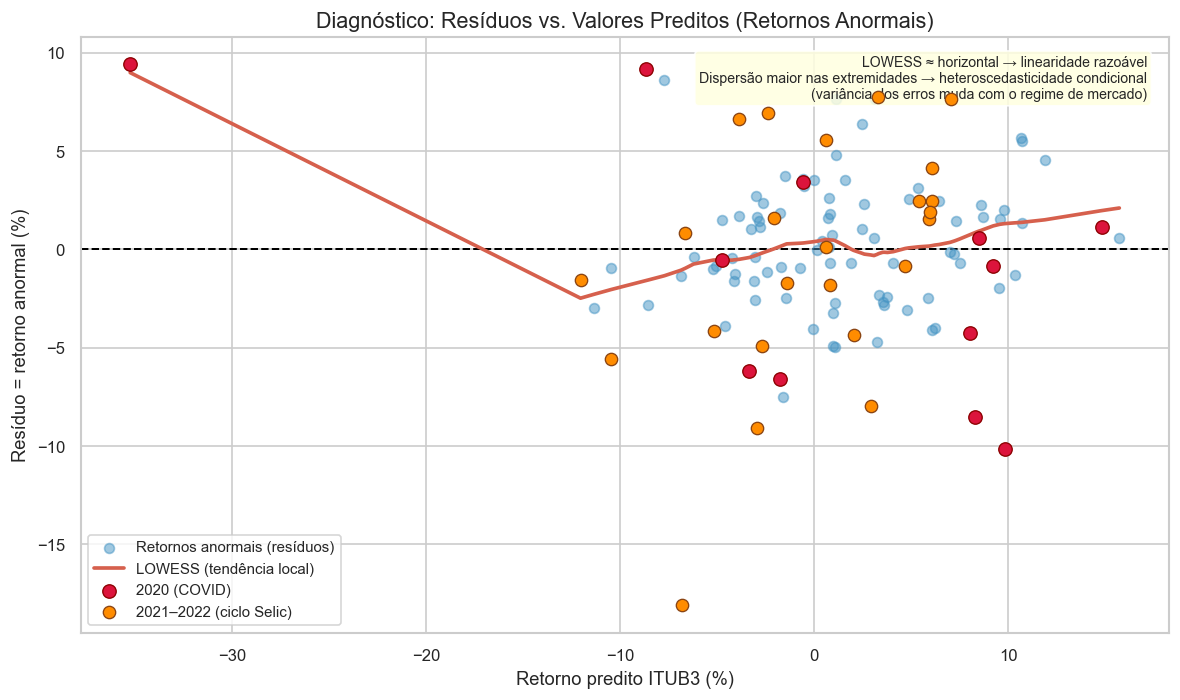

In [21]:
# LOWESS (Locally Weighted Scatterplot Smoothing): ajusta uma curva suave localmente
# sem assumir forma funcional — ideal para detectar padrões sistemáticos nos resíduos
# frac=0.4: cada ponto usa os 40% de vizinhos mais próximos para calcular a média local
# return_sorted=True: retorna os pontos ordenados por y_pred para que a linha seja contínua
smooth = lowess(residuos, y_pred, frac=0.4, return_sorted=True)

fig, ax = plt.subplots(figsize=(10, 6))

# Cada ponto é um mês: eixo X = o que o modelo previu, eixo Y = o erro que o modelo cometeu
# Em um modelo bem especificado, os resíduos ficam aleatoriamente em torno de zero,
# sem nenhum padrão discernível — o erro seria "ruído branco"
ax.scatter(y_pred * 100, residuos * 100,
           alpha=0.5, s=35, color='#4393c3', zorder=3, label='Retornos anormais (resíduos)')

# Linha de referência: resíduos perfeitamente aleatórios ficam em torno desta linha
ax.axhline(0, color='black', linewidth=1.2, linestyle='--')

# Curva LOWESS: se não for aproximadamente horizontal → há padrão sistemático → má especificação
ax.plot(smooth[:, 0] * 100, smooth[:, 1] * 100,
        color='#d6604d', linewidth=2.2, label='LOWESS (tendência local)', zorder=4)

# Pontos de 2020: crash COVID gerou retornos anormais extremos
# Esses meses concentram os maiores erros absolutos do modelo
mask_covid = df.index.year == 2020
ax.scatter(y_pred[mask_covid] * 100, residuos[mask_covid] * 100,
           color='crimson', s=65, zorder=5, edgecolors='darkred', linewidth=0.8,
           label='2020 (COVID)')

# Pontos de 2021-2022: alta da Selic beneficiou bancos de forma diferente do restante do Ibovespa
# Isso pode gerar resíduos sistematicamente positivos (modelo subestima ITUB3) no período
mask_selic = df.index.year.isin([2021, 2022])
ax.scatter(y_pred[mask_selic] * 100, residuos[mask_selic] * 100,
           color='darkorange', s=55, zorder=5, edgecolors='saddlebrown', linewidth=0.8,
           label='2021–2022 (ciclo Selic)')

ax.set_xlabel('Retorno predito ITUB3 (%)')
ax.set_ylabel('Resíduo = retorno anormal (%)')
ax.set_title('Diagnóstico: Resíduos vs. Valores Preditos (Retornos Anormais)')
ax.legend(fontsize=9)

ax.text(0.98, 0.97,
        'LOWESS ≈ horizontal → linearidade razoável\n'
        'Dispersão maior nas extremidades → heteroscedasticidade condicional\n'
        '(variância dos erros muda com o regime de mercado)',
        transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

plt.tight_layout()
plt.show()

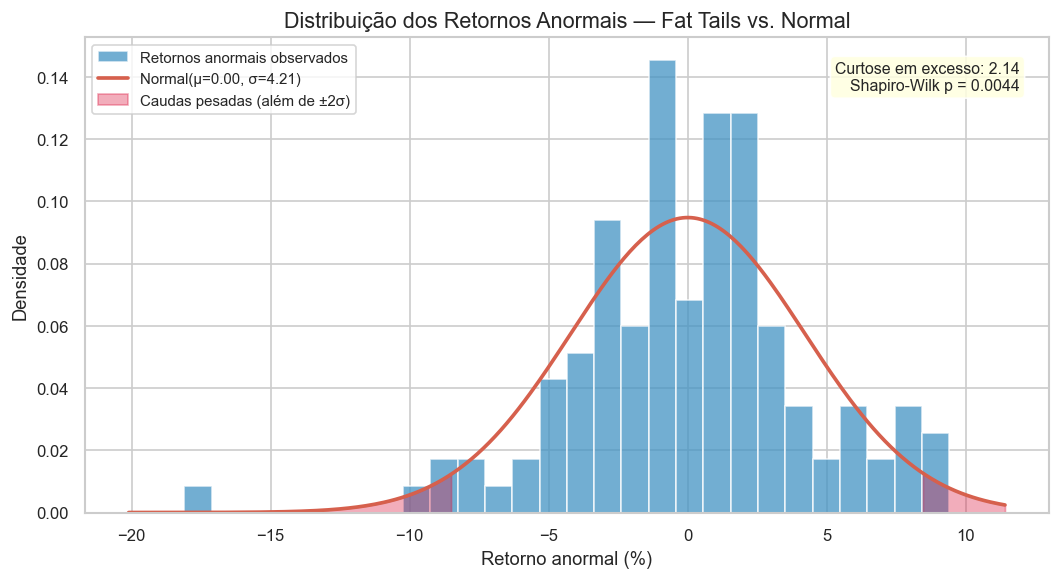

In [22]:
mu_e, sigma_e = (residuos * 100).mean(), (residuos * 100).std()
x_norm = np.linspace((residuos * 100).min() - 2, (residuos * 100).max() + 2, 300)

fig, ax = plt.subplots(figsize=(9, 5))

# density=True: normaliza o histograma para que a área total = 1 (densidade de probabilidade)
# Sem isso, o eixo Y seria contagem de observações e a curva PDF não teria a mesma escala
ax.hist(residuos * 100, bins=28, color='#4393c3', edgecolor='white', alpha=0.75,
        density=True, label='Retornos anormais observados')

# stats.norm.pdf(): função densidade de probabilidade da normal — devolve a altura da curva em cada x
# Usamos a normal com mesma média e desvio dos resíduos como referência teórica do OLS
ax.plot(x_norm, stats.norm.pdf(x_norm, mu_e, sigma_e),
        color='#d6604d', linewidth=2.2, label=f'Normal(μ={mu_e:.2f}, σ={sigma_e:.2f})')

# Sombreia as caudas além de ±2σ para evidenciar os eventos extremos
limiar = 2 * sigma_e
x_cauda_esq = x_norm[x_norm < mu_e - limiar]
x_cauda_dir = x_norm[x_norm > mu_e + limiar]
ax.fill_between(x_cauda_esq, stats.norm.pdf(x_cauda_esq, mu_e, sigma_e),
                color='crimson', alpha=0.35, label='Caudas pesadas (além de ±2σ)')
ax.fill_between(x_cauda_dir, stats.norm.pdf(x_cauda_dir, mu_e, sigma_e),
                color='crimson', alpha=0.35)

# stats.kurtosis(): retorna curtose em *excesso* — normal = 0 (não 3)
# Valores positivos indicam caudas mais pesadas que a normal (leptocúrtica)
kurt = stats.kurtosis(residuos)

# stats.shapiro(): teste Shapiro-Wilk de normalidade
# H0: "os dados vêm de uma distribuição normal"
# p < 0.05 → rejeitamos H0 → evidência de não-normalidade
stat_sw, p_sw = stats.shapiro(residuos)

ax.text(0.97, 0.95,
        f'Curtose em excesso: {kurt:.2f}\nShapiro-Wilk p = {p_sw:.4f}',
        transform=ax.transAxes, fontsize=9.5, va='top', ha='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('Retorno anormal (%)')
ax.set_ylabel('Densidade')
ax.set_title('Distribuição dos Retornos Anormais — Fat Tails vs. Normal')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
from statsmodels.stats.diagnostic import linear_reset
import statsmodels.api as sm

# RESET precisa de um modelo statsmodels — re-estimamos OLS com a mesma especificação
# Os coeficientes são idênticos ao sklearn; precisamos do objeto statsmodels para o teste
X_sm = sm.add_constant(df['r_ibov'].values)
modelo_sm = sm.OLS(df['r_itub'].values, X_sm).fit()

# Ramsey (1969): aumenta o modelo com ŷ² e ŷ³, testa se esses termos são conjuntamente
# significantes. Se forem, a forma linear não captura toda a estrutura dos dados.
# H0: γ₁ = γ₂ = 0  →  termos não-lineares são desnecessários  →  linear é adequado
# H1: pelo menos um γ ≠ 0  →  há não-linearidade ou variável omitida relevante
# power=3: inclui até ŷ³; use_f=True: estatística F (preferível ao χ² para n = 119)
reset = linear_reset(modelo_sm, power=3, use_f=True)

print('=== Teste RESET de Especificação Linear (Ramsey, 1969) — Premissa 1 ===')
print()
print('  H0: γ₁ = γ₂ = 0  →  especificação linear é adequada')
print('  H1: pelo menos um γ ≠ 0  →  não-linearidade ou variável omitida')
print()
print(f'  Estatística F : {reset.fvalue:.4f}')
print(f'  p-valor       : {reset.pvalue:.4f}')
print()
if reset.pvalue > 0.05:
    print(f'  → p = {reset.pvalue:.4f} > 0,05  |  NÃO rejeitamos H0')
    print(f'     A inspeção visual do LOWESS é confirmada formalmente:')
    print(f'     a especificação linear é estatisticamente adequada.')
else:
    print(f'  → p = {reset.pvalue:.4f} ≤ 0,05  |  REJEITAMOS H0')
    print(f'     O LOWESS horizontal é enganoso: há evidência de')
    print(f'     não-linearidade ou variável omitida relevante.')

=== Teste RESET de Especificação Linear (Ramsey, 1969) — Premissa 1 ===

  H0: γ₁ = γ₂ = 0  →  especificação linear é adequada
  H1: pelo menos um γ ≠ 0  →  não-linearidade ou variável omitida

  Estatística F : 3.4050
  p-valor       : 0.0366

  → p = 0.0366 ≤ 0,05  |  REJEITAMOS H0
     O LOWESS horizontal é enganoso: há evidência de
     não-linearidade ou variável omitida relevante.


Os diagnósticos visuais e os testes formais, lidos em conjunto, mapeiam três das quatro premissas do Gauss-Markov para este modelo.

**Premissa 1 — Linearidade: ⚠ SINAL DE ALERTA (RESET rejeita marginalmente H0)**
O LOWESS não exibe curvatura clara — mas inspeção visual é subjetiva. O **Teste RESET** fornece a afirmação formal: F = 3,41, p = 0,037. Rejeitamos H0 ao nível de 5%, mas *não* ao nível de 1%. O resultado é marginal.

O RESET não distingue entre três causas possíveis:

1. **Não-linearidade funcional real** — a relação r_ITUB3 ~ r_IBOV tem curvatura. Improvável: o LOWESS não exibe arco sistemático.
2. **Instabilidade de β no tempo** — um único coeficiente estimado sobre 10 anos suaviza regimes muito distintos (bull market, COVID, ciclo Selic). Médias locais de regimes diferentes não ficam perfeitamente numa reta; o RESET interpreta isso como não-linearidade.
3. **Beta assimétrico (downside vs. upside)** — ações financeiras pró-cíclicas frequentemente têm β maior em quedas do que em altas. Uma relação linear por partes aparece como curvatura para o RESET.

A heteroscedasticidade confirmada na Premissa 2 agrava o problema: erros com variância não-constante distorcem a distribuição F do teste, inflando a taxa de rejeição.

**Conclusão:** o β médio de 10 anos é uma simplificação que mascara variações de regime. A rejeição marginal do RESET é evidência de que essa simplificação tem custo — não de que regressão linear seja a ferramenta errada, mas de que **um único β estático não captura toda a dinâmica da relação**. É exatamente o que o Beta Rolling da Parte 2 investigará.

---

**Premissa 2 — Homocedasticidade: ✗ VIOLADA**
A dispersão dos resíduos é visivelmente maior nas extremidades — meses de retornos muito negativos (crises) ou muito positivos (recuperações). Isso é **heteroscedasticidade condicional**: a variância dos erros muda com o regime de mercado. Consequência: o OLS ainda produz β não-viesado, mas os erros-padrão estão subestimados e os intervalos de confiança são mais estreitos do que deveriam. Correção: erros-padrão robustos HC3 — Parte 2.

**Premissa 3 — Independência dos resíduos: ⚠ NÃO VERIFICADA**
A autocorrelação dos resíduos não foi testada. O teste adequado é o Durbin-Watson (ou ACF dos resíduos). Em séries de retornos mensais a autocorrelação tende a ser baixa, mas não é zero por garantia. Verificação formal na Parte 2.

**Premissa 4 — Normalidade dos resíduos: ✗ VIOLADA**
O histograma confirma caudas mais pesadas que a normal — evidência reforçada pela curtose em excesso e pelo Shapiro-Wilk. Esta é a premissa mais flexível: não é necessária para que β seja não-viesado. Torna-se relevante para inferência formal (t-tests, ICs), onde o Teorema Central do Limite atenua o problema com n = 119, mas não o elimina nas caudas.

Dois eventos concentram os maiores desvios. **Mar/2020** está longe da nuvem central — ponto de alta alavancagem com influência desproporcional sobre o Beta estimado. O **ciclo Selic 2021–2022** gerou resíduos sistematicamente positivos: a alta de juros de 2% para 13,75% beneficiou o Itaú (spreads maiores) enquanto prejudicou outros setores, criando uma dinâmica desacoplada do restante do Ibovespa.

**Resumo do diagnóstico:**

| Premissa | Status | Consequência para este notebook |
|---|---|---|
| Linearidade | ⚠ Sinal de alerta (RESET marginal, p = 0,037) | β estático de 10 anos mascara variação de regime — Beta Rolling na Parte 2 |
| Homocedasticidade | ✗ Violada | Erros-padrão subestimados; ICs mais estreitos do que deveriam |
| Independência | ⚠ Não verificada | Risco residual de erros-padrão incorretos |
| Normalidade | ✗ Violada | Inferência formal comprometida nas caudas |

O modelo é **útil para estimação pontual de β como referência histórica de longo prazo**. As violações indicam que a análise não termina aqui: a Parte 2 adiciona as correções de inferência e investiga a instabilidade temporal que o RESET sinalizou.

<a id="sec-deploy"></a>

---

## Fase 6 — Deployment (Implantação)

> *No CRISP-DM, Deployment é a entrega dos resultados ao usuário final. Aqui: o sumário executivo para o comitê de alocação — com o resultado, a incerteza e as limitações do modelo.*

O diagnóstico da Fase 5 confirma que o modelo funciona — com limites bem definidos. Antes de levar os números ao gestor, uma pergunta que o analista rigoroso não pode ignorar:

### A resposta é estatisticamente coerente?

| Componente da resposta | Status | O que suporta |
|---|---|---|
| **Direção:** ITUB3 cai com o Ibovespa | ✓ Conclusivo | r ≈ 0,84 com p-valor ≈ 0 |
| **Magnitude:** β ≈ 1 (ITUB3 replica o mercado) | ✓ Adequado para uso prático | R² = 0,71 + correlação |
| **Previsão pontual:** −9,8% | ✓ Válido como estimativa central | OLS; β não-viesado (linearidade satisfeita) |
| **Incerteza: ±4,2 p.p.** | ⚠ Aproximação — não é IC formal | RMSE in-sample; intervalo real é mais largo |
| **Teste H0: β = 1** | ✗ Não realizado | sklearn não fornece t-estatística |

**O intervalo ±4,2 p.p. subestima a incerteza real.** O RMSE mede o erro médio *in-sample*. O intervalo de predição correto para um ponto fora da amostra ($x_{\text{novo}} = -0{,}10$) é:

$$\hat{r}_{\text{ITUB3}} \pm t_{n-2,\,\alpha/2} \cdot s \cdot \sqrt{1 + \frac{1}{n} + \frac{(x_{\text{novo}} - \bar{x})^2}{\sum(x_t - \bar{x})^2}}$$

O terceiro termo sob a raiz — $(x_{\text{novo}} - \bar{x})^2$ — cresce com a distância do cenário à média histórica. Um cenário de −10% está bem longe da média mensal do Ibovespa (≈ +0,5%), o que aumenta a incerteza de predição além do RMSE. Adicionalmente, a heteroscedasticidade detectada na Fase 5 invalida os erros-padrão do OLS, tornando qualquer intervalo baseado neles formalmente incorreto.

**Conclusão:** a resposta é *adequada para tomada de decisão informada*, desde que comunicada com as ressalvas corretas. A previsão pontual (−9,8%) tem suporte estatístico sólido. O que carece de formalização é o intervalo de incerteza e o teste H0: β = 1 — lacunas que a Parte 2 fechará com `statsmodels` e erros robustos.

### O que levar para o gestor

In [24]:
print('=== Sumário executivo para o comitê de alocação ===')
print()
# Imprime a equação completa do modelo estimado
print(f'Modelo: r_ITUB3 = {alfa*100:.4f}% + {beta:.4f} × r_IBOV')
print(f'Período: 2015-2024 | {len(df)} observações mensais')
print()

# Classifica o ativo com base no Beta estimado
# β < 1 → defensivo (atenua mercado), β > 1 → agressivo (amplifica mercado)
classificacao = ('AGRESSIVO (amplifica o mercado)' if beta > 1
                 else 'DEFENSIVO (atenua o mercado)' if beta < 1
                 else 'NEUTRO (replica o mercado)')
print(f'1. Beta (β = {beta:.4f}): ativo {classificacao}')
print(f'   → Se o Ibovespa cair 10%, ITUB3 deve cair {abs(alfa + beta * (-0.10))*100:.1f}% em média')
print()

# (1 + alfa)^12 − 1: anualiza o retorno mensal composto
print(f'2. Alfa de Jensen (α = {alfa*100:.4f}% a.m. | {((1+alfa)**12-1)*100:+.2f}% a.a.):')
print(f'   → Com {len(df)} obs. e RMSE de {rmse*100:.2f} p.p., este α não é distinguível de zero')
print(f'      sem teste formal — intervalo de confiança e t-test calculados na Parte 2')
print()

# R²: fração do risco total que é sistemático (= não diversificável)
print(f'3. R² = {r2:.4f}: {r2*100:.0f}% do risco de ITUB3 é sistemático (mercado)')
print(f'   → {(1-r2)*100:.0f}% é idiossincrático (banco) — pode ser diluído por diversificação')
print()

# RMSE: erro médio do modelo na unidade original — útil para comunicar incerteza ao comitê
print(f'4. RMSE = {rmse*100:.2f} p.p.: incerteza mensal residual do modelo')
print()
print('=== Limitações a comunicar ===')
print(f'  • Beta estimado é uma média histórica — varia com o ciclo econômico')
print(f'  • Crash COVID (mar/2020) exerce influência alta sobre β — ponto de alavancagem')
print(f'  • Resíduos com heteroscedasticidade → erros-padrão do OLS subestimados')
print(f'  • Um único fator: Fama-French (3 ou 5 fatores) capturaria mais variação')
print(f'  • ITUB3 compõe o Ibovespa (~3–7% de peso): correlação tem componente mecânico')
print(f'    → Beta ligeiramente inflado; solução rigorosa usaria Ibovespa ex-ITUB3')

=== Sumário executivo para o comitê de alocação ===

Modelo: r_ITUB3 = 0.1157% + 0.9956 × r_IBOV
Período: 2015-2024 | 119 observações mensais

1. Beta (β = 0.9956): ativo DEFENSIVO (atenua o mercado)
   → Se o Ibovespa cair 10%, ITUB3 deve cair 9.8% em média

2. Alfa de Jensen (α = 0.1157% a.m. | +1.40% a.a.):
   → Com 119 obs. e RMSE de 4.21 p.p., este α não é distinguível de zero
      sem teste formal — intervalo de confiança e t-test calculados na Parte 2

3. R² = 0.7076: 71% do risco de ITUB3 é sistemático (mercado)
   → 29% é idiossincrático (banco) — pode ser diluído por diversificação

4. RMSE = 4.21 p.p.: incerteza mensal residual do modelo

=== Limitações a comunicar ===
  • Beta estimado é uma média histórica — varia com o ciclo econômico
  • Crash COVID (mar/2020) exerce influência alta sobre β — ponto de alavancagem
  • Resíduos com heteroscedasticidade → erros-padrão do OLS subestimados
  • Um único fator: Fama-French (3 ou 5 fatores) capturaria mais variação
  • ITUB3 co

### Limitações do modelo

Todo modelo honesto carrega ressalvas. As cinco abaixo são as mais relevantes para decisões de alocação:

| Limitação | Evidência | Próximo passo |
|---|---|---|
| Beta instável no tempo | Regimes distintos em 10 anos | Beta Rolling (janela 24 meses) |
| Heteroscedasticidade | Dispersão maior em crises | HC3 ou GARCH |
| Ponto de alta influência | Mar/2020 domina o scatter | Distância de Cook; janela sem COVID |
| Um único fator | R² = 71% — 29% não explicado | Fama-French 3 ou 5 fatores |
| Componente mecânico | ITUB3 compõe o Ibovespa | Ibovespa ex-ITUB3 |

---

### O ciclo CRISP-DM se fecha — e recomeça

No CRISP-DM, a Fase 6 não é o fim: as limitações identificadas na **Fase 5 (Evaluation)** retroalimentam a **Fase 1 (Business Understanding)** do próximo ciclo. Cada linha da tabela acima é uma hipótese de melhoria — e cada hipótese vira um novo projeto:

```
Fase 5: "resíduos têm heteroscedasticidade"
  → Fase 1 da Parte 2: "o Beta varia com o regime?"
    → Fase 4: Beta Rolling
      → Fase 5: "o Beta Rolling é estável?"
        → ...
```

É assim que projetos de dados evoluem: não em linha reta, mas em espirais que refinam o modelo a cada volta.

---

> *« Un des torts de quelques philosophes de ce temps, c'est de vouloir bannir les hypothèses de la physique ; elles y sont aussi nécessaires que les échafauds dans une maison que l'on bâtit ; il est vrai que lorsque le bâtiment est achevé, les échafauds deviennent inutiles, mais on n'aurait pu l'élever sans leur secours. »*
>
> — Émilie du Châtelet, *Institutions de Physique*, Cap. IV "Des Hypothèses", 1740
>
> *"Um dos erros de alguns filósofos do nosso tempo é querer banir as hipóteses da física; elas são tão necessárias quanto o andaime numa casa em construção — quando o edifício está pronto, o andaime se torna inútil, mas jamais se poderia tê-lo erguido sem ele."*
>
> O CAPM é o andaime. O CRISP-DM é o processo de construção. Simplifica a realidade — um único fator, mercado eficiente, retornos normais — mas foi exatamente essa simplicidade que tornou possível quantificar o risco sistemático, estimar o Beta e responder à pergunta do gestor. O que separa o analista que usa o modelo com inteligência do que o usa com ingenuidade é o que fizemos aqui: entender os pressupostos, executar os diagnósticos e comunicar as limitações antes de tomar decisões.